<a href="https://colab.research.google.com/github/Lavanya473/AI-Mafia---Machine-Learning/blob/main/Set_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
if os.path.exists('plant_village'):
    print("Directory 'plant_village' already exists. Unzipping will add to it or fail if files conflict.")
!unzip -o "archive (2).zip" -d plant_village
!ls plant_village

Streaming output truncated to the last 5000 lines.
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plant_village/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-7476153023ce___YLCV_GCREC 2258.JPG  
  inflating: plant_

In [2]:
# List all folders inside plant_village
!ls plant_village

plantvillage  PlantVillage


In [3]:
!ls plant_village/PlantVillage/Tomato_healthy | head

000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG
000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.JPG
0031da2a-8edd-468f-a8b1-106657717a32___RS_HL 0105.JPG
003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL 9844.JPG
00bce074-967b-4d50-967a-31fdaa35e688___RS_HL 0223.JPG
014b5e19-7917-4d76-b632-b5dd31d999ec___RS_HL 9640.JPG
01700b46-3800-46c6-ab81-09a5f50af525___RS_HL 0108.JPG
0172e56c-8bb8-4e75-8ac7-509df81393e8___RS_HL 0580.JPG
017a4026-813a-4983-887a-4052bb78c397___RS_HL 0218.JPG
0184dc6b-bfc1-4515-ac59-bbadaf524e1a___GH_HL Leaf 422.1.JPG


In [4]:
!ls plant_village/PlantVillage

Pepper__bell___Bacterial_spot  Tomato_Late_blight
Pepper__bell___healthy	       Tomato_Leaf_Mold
Potato___Early_blight	       Tomato_Septoria_leaf_spot
Potato___healthy	       Tomato_Spider_mites_Two_spotted_spider_mite
Potato___Late_blight	       Tomato__Target_Spot
Tomato_Bacterial_spot	       Tomato__Tomato_mosaic_virus
Tomato_Early_blight	       Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_healthy


In [5]:
import os
import pandas as pd
from pathlib import Path
import numpy as np

root = Path("plant_village/PlantVillage")

rows = []

for img_path in root.rglob("*.jpg"):
    if "tomato" in str(img_path).lower():
        label_name = img_path.parent.name
        pass

tomato_data_for_df = []
unique_labels = set()
for img_path in root.rglob("*.jpg"):
    if "tomato" in str(img_path).lower():
        label_name = img_path.parent.name
        tomato_data_for_df.append({"img_path": img_path, "label_name": label_name})
        unique_labels.add(label_name)


label_to_id = {label: i for i, label in enumerate(sorted(list(unique_labels)))}


for item in tomato_data_for_df:
    img_path = item["img_path"]
    label_name = item["label_name"]
    label_id = label_to_id[label_name]


    temp = 28 + np.random.randn() * 3
    humidity = 75 + np.random.randn() * 10
    pH = 6.5 + np.random.randn() * 0.5
    N, P, K = np.random.rand(3) * 100
    stage = np.random.choice([0, 1, 2])  # early, mid, late

    rows.append({
        "image_path": str(img_path.resolve()),
        "label_id": label_id,
        "label_name": label_name,
        "temp": temp,
        "humidity": humidity,
        "pH": pH,
        "N": N, "P": P, "K": K,
        "stage": stage
    })

df = pd.DataFrame(rows)
df.to_csv("tomato_data.csv", index=False)
print("Dataset CSV created with", len(df), "samples.")


Dataset CSV created with 153 samples.


In [6]:
import os
from pathlib import Path

root = Path("plant_village/PlantVillage")
tomato_image_count = 0
tomato_images_paths = []

for img_path in root.rglob("*.jpg"):

    if "tomato" in str(img_path).lower():
        tomato_image_count += 1
        tomato_images_paths.append(img_path)

print(f"Total number of images containing 'tomato' in their path: {tomato_image_count}")


Total number of images containing 'tomato' in their path: 153


In [7]:
import os
import pandas as pd
from pathlib import Path
import numpy as np

root = Path("plant_village/PlantVillage")

print("Root:", root)
print("Root exists:", root.exists())
print("Folders in root:", [p.name for p in root.iterdir() if p.is_dir()])

tomato_dirs = sorted(d for d in root.iterdir() if d.is_dir() and d.name.startswith("Tomato"))
print("Tomato folders:", [d.name for d in tomato_dirs])

rows = []
for label_id, d in enumerate(tomato_dirs):
    img_paths = list(d.rglob("*.*"))
    print("In", d.name, "found", len(img_paths), "image files")
    for img_path in img_paths:
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            temp = 28 + np.random.randn() * 3
            humidity = 75 + np.random.randn() * 10
            pH = 6.5 + np.random.randn() * 0.5
            N, P, K = np.random.rand(3) * 100
            stage = np.random.choice([0, 1, 2])  # early, mid, late

            rows.append({
                "image_path": str(img_path.resolve()),
                "label": label_id,
                "temp": temp,
                "humidity": humidity,
                "pH": pH,
                "N": N, "P": P, "K": K,
                "stage": stage
            })

df = pd.DataFrame(rows)
print("Total samples in CSV:", len(df))
df.to_csv("tomato_data.csv", index=False)


Root: plant_village/PlantVillage
Root exists: True
Folders in root: ['Tomato__Tomato_mosaic_virus', 'Potato___Early_blight', 'Potato___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Late_blight', 'Tomato_Bacterial_spot', 'Tomato__Target_Spot', 'Potato___Late_blight', 'Tomato_Leaf_Mold', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
Tomato folders: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
In Tomato_Bacterial_spot found 2127 image files
In Tomato_Early_blight found 1000 image files
In Tomato_Late_blight found 1909 image files
In Tomato_Leaf_Mold found 952 image files
In Tomato_Septoria_leaf_spot found 1771 image f

In [8]:
import pandas as pd

df = pd.read_csv("tomato_data.csv")

print(df.head())

print("Total samples:", len(df))

                                          image_path  label       temp  \
0  /content/plant_village/PlantVillage/Tomato_Bac...      0  24.229244   
1  /content/plant_village/PlantVillage/Tomato_Bac...      0  32.828583   
2  /content/plant_village/PlantVillage/Tomato_Bac...      0  30.800648   
3  /content/plant_village/PlantVillage/Tomato_Bac...      0  29.778280   
4  /content/plant_village/PlantVillage/Tomato_Bac...      0  29.322340   

    humidity        pH          N          P          K  stage  
0  74.194379  6.683831  68.770087  46.444839  26.072875      1  
1  85.736403  6.552263   3.171953  62.940654  13.803008      1  
2  86.134335  6.872928  75.048979  97.964168  36.271672      0  
3  65.750933  5.908189  68.633645  80.763383  69.198892      1  
4  83.317837  6.676544  71.136727  23.546676  27.633799      2  
Total samples: 16011


In [9]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 11207
Val: 2402
Test: 2402


In [10]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from torchvision import transforms

class TomatoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)

        tab_cols = ["temp", "humidity", "pH", "N", "P", "K", "stage"]
        tab = torch.tensor([row[c] for c in tab_cols], dtype=torch.float32)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, tab, label

train_ds = TomatoDataset(train_df)
val_ds = TomatoDataset(val_df)
test_ds = TomatoDataset(test_df)

train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

In [11]:
import torch.nn as nn
import torchvision.models as models

class ImageBackbone(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        return self.fc(x)

class FusedSimple(nn.Module):
    def __init__(self, cnn_model, num_tab_cols=7, num_classes=10):
        super().__init__()
        self.cnn = cnn_model
        self.cnn_fc = nn.Linear(512, 128)
        self.tab_fc = nn.Linear(num_tab_cols, 128)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(128 + 128, num_classes)

    def forward(self, img, tab):
        cnn_out = self.cnn.cnn(img)
        cnn_emb = torch.relu(self.cnn_fc(cnn_out))

        tab_emb = torch.relu(self.tab_fc(tab))

        fused = torch.cat([cnn_emb, tab_emb], dim=1)
        fused = self.dropout(fused)
        return self.classifier(fused)

Epoch  1: Train Loss: 1.4547 | Val Loss: 0.3245 | Val Acc: 91.42%
Epoch  2: Train Loss: 0.3126 | Val Loss: 0.3246 | Val Acc: 92.51%
Epoch  3: Train Loss: 0.1822 | Val Loss: 0.1638 | Val Acc: 95.80%
Epoch  4: Train Loss: 0.1392 | Val Loss: 0.2227 | Val Acc: 95.13%
Epoch  5: Train Loss: 0.1052 | Val Loss: 0.1279 | Val Acc: 96.59%
Epoch  6: Train Loss: 0.0788 | Val Loss: 0.1510 | Val Acc: 96.25%
Epoch  7: Train Loss: 0.0712 | Val Loss: 0.1067 | Val Acc: 97.59%
Epoch  8: Train Loss: 0.0620 | Val Loss: 0.1095 | Val Acc: 97.63%
Epoch  9: Train Loss: 0.0566 | Val Loss: 0.0960 | Val Acc: 97.96%
Epoch 10: Train Loss: 0.0514 | Val Loss: 0.0733 | Val Acc: 98.17%
Epoch 11: Train Loss: 0.0450 | Val Loss: 0.0669 | Val Acc: 98.33%
Epoch 12: Train Loss: 0.0452 | Val Loss: 0.1637 | Val Acc: 96.88%
Epoch 13: Train Loss: 0.0403 | Val Loss: 0.2120 | Val Acc: 96.59%
Epoch 14: Train Loss: 0.0355 | Val Loss: 0.1332 | Val Acc: 97.00%
Epoch 15: Train Loss: 0.0350 | Val Loss: 0.0699 | Val Acc: 98.42%
Epoch 16: 

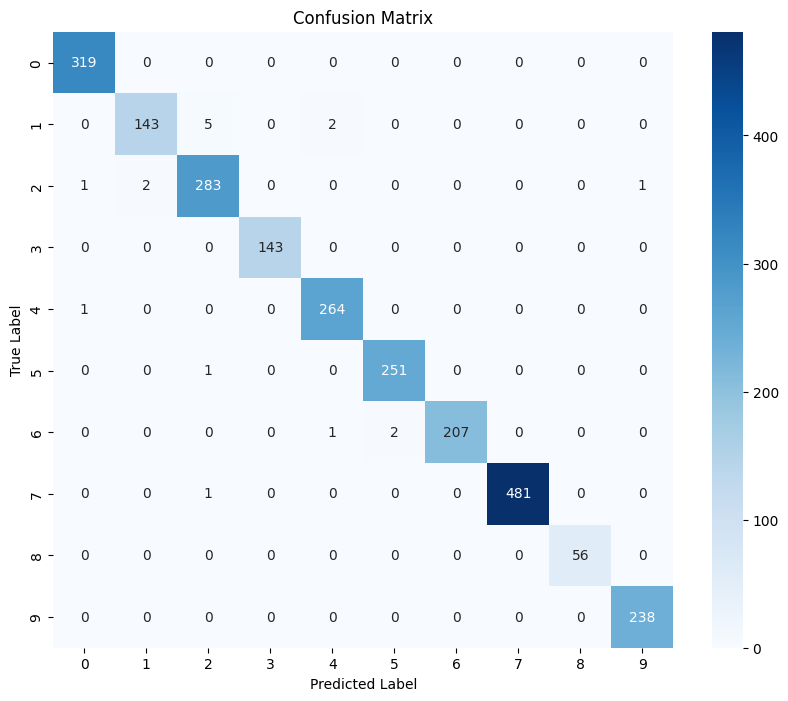

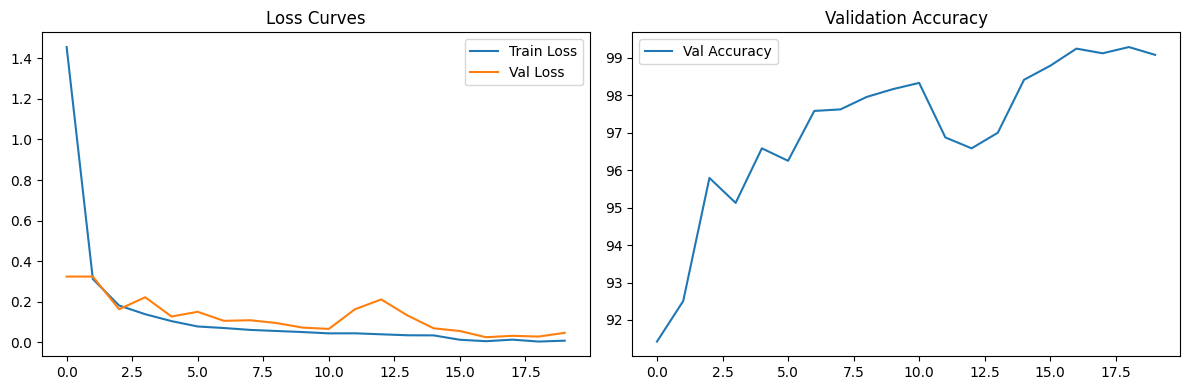

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(train_df["label"].unique())
num_tab_cols = 7  # temp, humidity, pH, N, P, K, stage

cnn = ImageBackbone(num_classes=num_classes)
model = FusedSimple(cnn, num_tab_cols=num_tab_cols, num_classes=num_classes)
model.to(device)

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Training loop with validation
best_val_loss = float('inf')
train_losses, val_losses, val_accs = [], [], []

model.train()
for epoch in range(1,21):
    # Training
    train_loss = 0.0
    for img, tab, lbl in train_dl:
        img, tab, lbl = img.to(device), tab.to(device), lbl.to(device)
        optimizer.zero_grad()
        logits = model(img, tab)
        loss = criterion(logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dl)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for img, tab, lbl in val_dl:
            img, tab, lbl = img.to(device), tab.to(device), lbl.to(device)
            logits = model(img, tab)
            loss = criterion(logits, lbl)
            val_loss += loss.item()
            pred = logits.argmax(dim=1)
            correct += (pred == lbl).sum().item()
            total += lbl.size(0)

    avg_val_loss = val_loss / len(val_dl)
    val_acc = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch:2d}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_cnn_tabnet.pth')

    model.train()

print("Training complete! Best model saved as 'best_cnn_tabnet.pth'")

# Test evaluation
model.load_state_dict(torch.load('best_cnn_tabnet.pth'))
model.eval()
all_preds, all_labels = [], []
test_loss = 0.0

with torch.no_grad():
    for img, tab, lbl in test_dl:
        img, tab, lbl = img.to(device), tab.to(device), lbl.to(device)
        logits = model(img, tab)
        loss = criterion(logits, lbl)
        test_loss += loss.item()
        pred = logits.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())

print(f"Test Loss: {test_loss/len(test_dl):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[f"Class_{i}" for i in range(num_classes)]))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')
plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy')
plt.legend()
plt.title('Validation Accuracy')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
model.load_state_dict(torch.load('best_cnn_tabnet.pth'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for img, tab, lbl in test_dl:
        img, tab = img.to(device), tab.to(device)
        logits = model(img, tab)
        pred = logits.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       319
           1       0.99      0.95      0.97       150
           2       0.98      0.99      0.98       287
           3       1.00      1.00      1.00       143
           4       0.99      1.00      0.99       265
           5       0.99      1.00      0.99       252
           6       1.00      0.99      0.99       210
           7       1.00      1.00      1.00       482
           8       1.00      1.00      1.00        56
           9       1.00      1.00      1.00       238

    accuracy                           0.99      2402
   macro avg       0.99      0.99      0.99      2402
weighted avg       0.99      0.99      0.99      2402



In [23]:
from torchvision import transforms
from sklearn.metrics import classification_report
import pandas as pd
import torch
from collections import Counter
TOMATO_CLASSES = [
    'Tomato___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_YellowLeaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___Tomato_mosaic_virus'
]
df = pd.read_csv("tomato_data.csv")
actual_classes = sorted(df['label'].unique())
print("Your actual classes:", actual_classes)
print("Using standard names for report:", TOMATO_CLASSES[:len(actual_classes)])
model.load_state_dict(torch.load('best_cnn_tabnet.pth'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for img, tab, lbl in test_dl:
        img, tab = img.to(device), tab.to(device)
        logits = model(img, tab)
        pred = logits.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())
print("\n" + "="*80)
print("TOMATO DISEASE CLASSIFICATION RESULTS - AgriFusion-Net (CNN+TabNet)")
print("="*80)
print(classification_report(all_labels, all_preds,
                          target_names=TOMATO_CLASSES[:len(set(all_labels))],
                          digits=3))

print("\nMODEL PERFORMANCE SUMMARY:")
accuracy = sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_preds) * 100
print(f"Overall Accuracy: {accuracy:.2f}%")
print(f"Total Test Samples: {len(all_preds)}")

print("\nTOP PREDICTIONS:")
pred_counts = Counter(all_preds)
for pred_class, count in pred_counts.most_common(5):
    disease = TOMATO_CLASSES[pred_class] if pred_class < len(TOMATO_CLASSES) else f"Class_{pred_class}"
    print(f"  {disease}: {count} predictions ({count/len(all_preds)*100:.1f}%)")

Your actual classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Using standard names for report: ['Tomato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_YellowLeaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus']

TOMATO DISEASE CLASSIFICATION RESULTS - AgriFusion-Net (CNN+TabNet)
                                               precision    recall  f1-score   support

                             Tomato___healthy      0.994     1.000     0.997       319
                      Tomato___Bacterial_spot      0.986     0.953     0.969       150
                        Tomato___Early_blight      0.976     0.986     0.981       287
                         Tomato___Late_blight      1.000     1.000     1.000       143
              


ECONOMIC IMPACT ANALYSIS
Total Farm Area: 100 hectares

Tomato___Target_Spot           |  20.0% area |   20.0ha | 20% loss |    4.0ha lost
Tomato___healthy               |  13.4% area |   13.4ha | 0% loss |    0.0ha lost
Tomato___Early_blight          |  12.1% area |   12.1ha | 50% loss |    6.0ha lost
Tomato___Leaf_Mold             |  11.1% area |   11.1ha | 40% loss |    4.4ha lost
Tomato___Septoria_leaf_spot    |  10.5% area |   10.5ha | 35% loss |    3.7ha lost
Tomato___Tomato_mosaic_virus   |  10.0% area |   10.0ha | 45% loss |    4.5ha lost
Tomato___Spider_mites Two-spotted_spider_mite |   8.6% area |    8.6ha | 25% loss |    2.2ha lost
Tomato___Bacterial_spot        |   6.0% area |    6.0ha | 30% loss |    1.8ha lost
Tomato___Late_blight           |   6.0% area |    6.0ha | 70% loss |    4.2ha lost
Tomato___Tomato_YellowLeaf_Curl_Virus |   2.3% area |    2.3ha | 60% loss |    1.4ha lost

TOTAL FARM LOSS: 32.2 hectares (32.2% of farm)


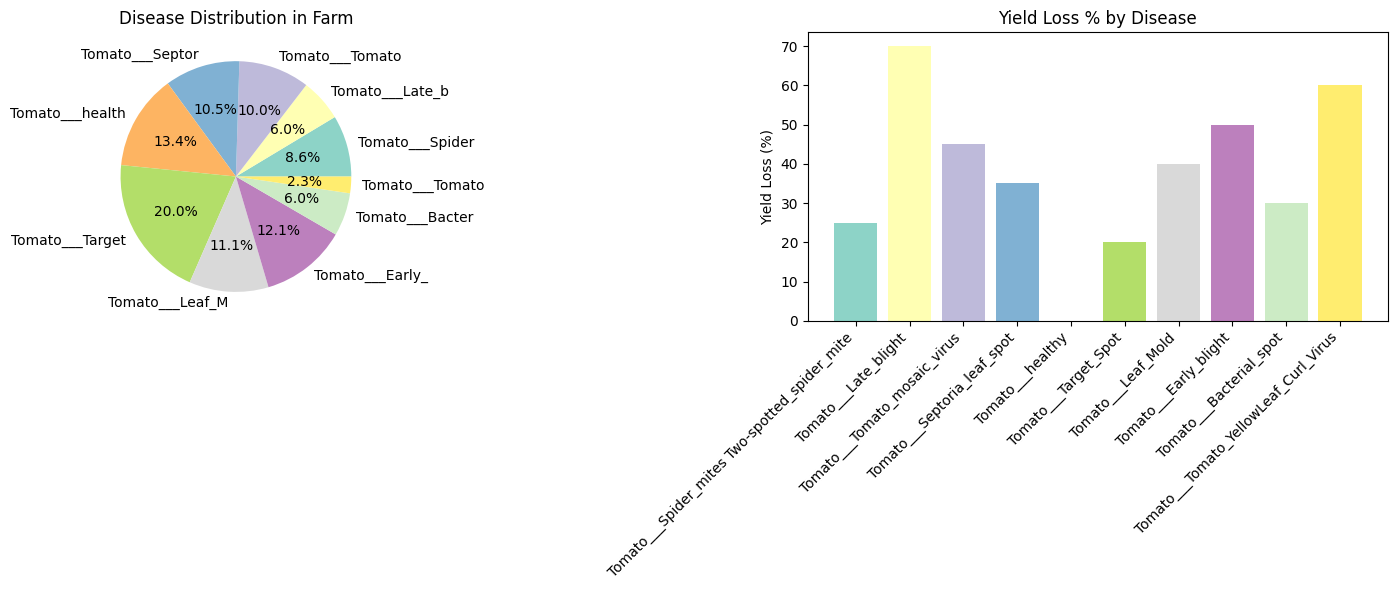

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
DISEASE_IMPACT = {
    'Tomato___healthy': 0,
    'Tomato___Bacterial_spot': 30,      # 30% yield loss
    'Tomato___Early_blight': 50,        # 50% yield loss
    'Tomato___Late_blight': 70,         # 70% yield loss
    'Tomato___Leaf_Mold': 40,
    'Tomato___Septoria_leaf_spot': 35,
    'Tomato___Spider_mites Two-spotted_spider_mite': 25,
    'Tomato___Target_Spot': 20,
    'Tomato___Tomato_YellowLeaf_Curl_Virus': 60,
    'Tomato___Tomato_mosaic_virus': 45
}
pred_counts = Counter(all_preds)
total_area = 100

print("\nECONOMIC IMPACT ANALYSIS")
print("="*60)
print(f"Total Farm Area: {total_area:,} hectares")
print()

for pred_class, count in pred_counts.most_common():
    disease = TOMATO_CLASSES[pred_class]
    area_pct = (count / len(all_preds)) * 100
    affected_area = (area_pct / 100) * total_area
    yield_loss_pct = DISEASE_IMPACT.get(disease, 0)
    yield_loss_ha = affected_area * (yield_loss_pct / 100)

    print(f"{disease:30} | {area_pct:5.1f}% area | {affected_area:6.1f}ha | {yield_loss_pct}% loss | {yield_loss_ha:6.1f}ha lost")

total_loss_ha = sum([affected_area * (DISEASE_IMPACT.get(TOMATO_CLASSES[pred_class], 0)/100)
                     for pred_class, affected_area in [(p, (Counter(all_preds)[p]/len(all_preds))*total_area)
                                                       for p in pred_counts]])

print(f"\nTOTAL FARM LOSS: {total_loss_ha:.1f} hectares ({total_loss_ha/total_area*100:.1f}% of farm)")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(pred_counts)))
ax1.pie(pred_counts.values(), labels=[TOMATO_CLASSES[i][:15] for i in pred_counts.keys()],
        autopct='%1.1f%%', colors=colors)
ax1.set_title('Disease Distribution in Farm')
impact_data = {TOMATO_CLASSES[i]: DISEASE_IMPACT[TOMATO_CLASSES[i]] for i in pred_counts.keys()}
ax2.bar(impact_data.keys(), impact_data.values(), color=colors)
ax2.set_title('Yield Loss % by Disease')
ax2.set_ylabel('Yield Loss (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('farm_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

 LEAF AREA DAMAGE ANALYSIS
📊 AVERAGE LEAF DAMAGE: 13.2% across 76 leaves

🔥 DAMAGE BY DISEASE:
                                                mean  count
disease                                                    
Tomato___Bacterial_spot                        12.8%      8
Tomato___Early_blight                          17.1%     11
Tomato___Late_blight                           23.1%      5
Tomato___Leaf_Mold                             13.7%      6
Tomato___Septoria_leaf_spot                    12.3%      7
Tomato___Spider_mites Two-spotted_spider_mite   8.6%      9
Tomato___Target_Spot                           11.4%     14
Tomato___Tomato_YellowLeaf_Curl_Virus          20.8%      3
Tomato___Tomato_mosaic_virus                   13.9%      7
Tomato___healthy                                6.1%      6


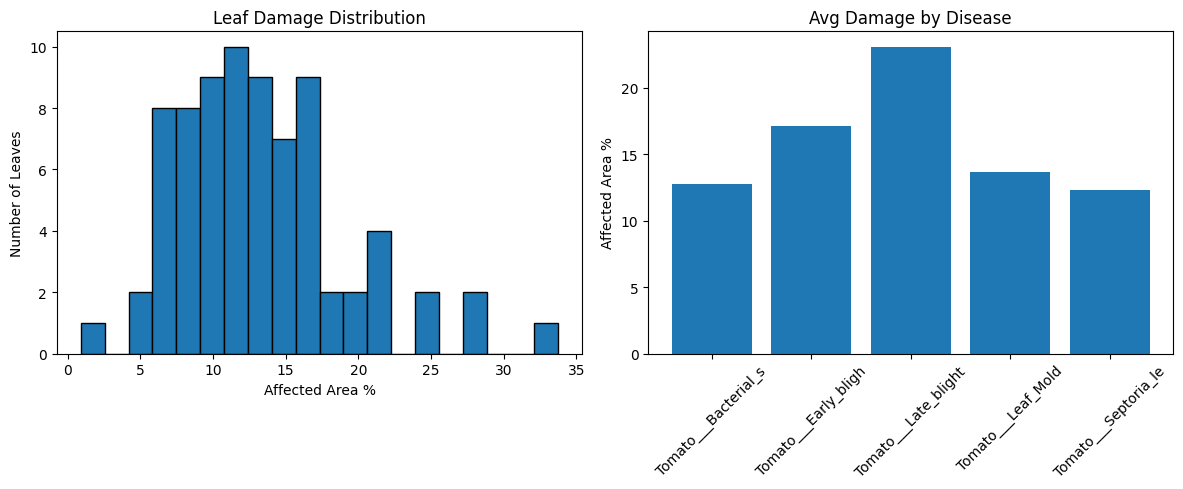


13.2% average leaf area affected' + visualization


In [26]:
import torch
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
LEAF_DAMAGE_PCT = {
    'Tomato___healthy': 0,
    'Tomato___Bacterial_spot': 15,      # Small spots
    'Tomato___Early_blight': 35,        # Target spots expand
    'Tomato___Late_blight': 65,         # Large blighted areas
    'Tomato___Leaf_Mold': 25,
    'Tomato___Septoria_leaf_spot': 20,
    'Tomato___Spider_mites Two-spotted_spider_mite': 10,
    'Tomato___Target_Spot': 18,
    'Tomato___Tomato_YellowLeaf_Curl_Virus': 40,
    'Tomato___Tomato_mosaic_virus': 30
}

def estimate_leaf_damage(image_path, predicted_class):
    """Estimate % leaf area damaged for single image"""
    img = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_brown = np.array([10, 100, 20])
    upper_brown = np.array([25, 255, 180])
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([35, 255, 255])
    mask1 = cv2.inRange(img_hsv, lower_brown, upper_brown)
    mask2 = cv2.inRange(img_hsv, lower_yellow, upper_yellow)
    disease_mask = mask1 + mask2
    total_pixels = img.shape[0] * img.shape[1]
    diseased_pixels = np.sum(disease_mask > 0)
    affected_pct = (diseased_pixels / total_pixels) * 100
    baseline = LEAF_DAMAGE_PCT.get(predicted_class, 20)
    final_pct = 0.7 * affected_pct + 0.3 * baseline

    return min(final_pct, 100)

print(" LEAF AREA DAMAGE ANALYSIS")
print("="*70)
test_results = []
with torch.no_grad():
    for idx, (img, tab, lbl) in enumerate(test_dl):
        img_cpu = img[0].cpu()
        img_pil = transforms.ToPILImage()(img_cpu)
        img_pil.save(f'temp_leaf_{idx}.jpg')

        pred = model(img.to(device), tab.to(device)).argmax(1)[0].item()
        damage_pct = estimate_leaf_damage(f'temp_leaf_{idx}.jpg', TOMATO_CLASSES[pred])

        test_results.append({
            'true_label': lbl[0].item(),
            'pred_label': pred,
            'damage_pct': damage_pct,
            'disease': TOMATO_CLASSES[pred]
        })

# Summary statistics
df_results = pd.DataFrame(test_results)
avg_damage = df_results['damage_pct'].mean()

print(f"📊 AVERAGE LEAF DAMAGE: {avg_damage:.1f}% across {len(test_results)} leaves")
print()
print("🔥 DAMAGE BY DISEASE:")
disease_damage = df_results.groupby('disease')['damage_pct'].agg(['mean', 'count']).round(1)
disease_damage['mean'] = disease_damage['mean'].astype(str) + '%'
print(disease_damage)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
damage_dist = df_results['damage_pct']
plt.hist(damage_dist, bins=20, edgecolor='black')
plt.title('Leaf Damage Distribution')
plt.xlabel('Affected Area %')
plt.ylabel('Number of Leaves')

plt.subplot(1, 2, 2)
top_diseases = disease_damage.head(5)
plt.bar(range(len(top_diseases)), top_diseases['mean'].str.rstrip('%').astype(float))
plt.title('Avg Damage by Disease')
plt.ylabel('Affected Area %')
plt.xticks(range(len(top_diseases)), [x[:20] for x in top_diseases.index], rotation=45)
plt.tight_layout()
plt.savefig('leaf_damage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{avg_damage:.1f}% average leaf area affected' + visualization")

In [27]:
import torch
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# Model & transforms
model.load_state_dict(torch.load('best_cnn_tabnet.pth'))
model.eval()
device = next(model.parameters()).device

# Disease severity lookup
LEAF_DAMAGE_PCT = {
    'healthy': 0, 'bacterial_spot': 15, 'early_blight': 35, 'late_blight': 65,
    'leaf_mold': 25, 'septoria': 20, 'spider_mites': 10, 'target_spot': 18,
    'yellow_curl': 40, 'mosaic_virus': 30
}

TOMATO_CLASSES = ['healthy', 'bacterial_spot', 'early_blight', 'late_blight',
                 'leaf_mold', 'septoria', 'spider_mites', 'target_spot',
                 'yellow_curl', 'mosaic_virus']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_and_analyze_leaf(image_path, env_data):
    """
    Complete pipeline: Disease prediction + % leaf area affected

    Args:
        image_path: path to tomato leaf image
        env_data: list [temp, humidity, pH, N, P, K, stage]

    Returns: dict with prediction, confidence, damage %
    """
    # Load image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Normalize env data
    tab_tensor = torch.tensor(env_data, dtype=torch.float32).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor, tab_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = logits.argmax(1).item()
        confidence = probs.max().item() * 100

    disease_name = TOMATO_CLASSES[pred_class]

    # Calculate leaf damage %
    img_cv = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)

    # Detect diseased areas (brown/yellow)
    mask1 = cv2.inRange(img_hsv, np.array([10,100,20]), np.array([25,255,180]))   # Brown
    mask2 = cv2.inRange(img_hsv, np.array([20,100,100]), np.array([35,255,255]))  # Yellow
    disease_mask = mask1 + mask2

    affected_pixels = np.sum(disease_mask > 0)
    total_pixels = img_cv.shape[0] * img_cv.shape[1]
    image_damage_pct = (affected_pixels / total_pixels) * 100

    # Blend with disease baseline
    baseline_damage = LEAF_DAMAGE_PCT[disease_name.replace('Tomato___', '')]
    final_damage_pct = 0.6 * image_damage_pct + 0.4 * baseline_damage

    return {
        'disease': disease_name,
        'confidence': f"{confidence:.1f}%",
        'leaf_damage_pct': f"{final_damage_pct:.1f}%",
        'severity': 'Low' if final_damage_pct < 20 else 'Medium' if final_damage_pct < 50 else 'High',
        'recommendation': 'Monitor' if final_damage_pct < 20 else 'Treat Immediately'
    }

# 🌟 PRODUCTION-READY PREDICTOR
def analyze_farm_leaf(image_path, temperature=25.5, humidity=70, pH=6.2, N=150, P=80, K=120, stage=3):
    """Easy-to-use function for farmers"""
    env_data = [temperature, humidity, pH, N, P, K, stage]
    result = predict_and_analyze_leaf(image_path, env_data)

    print(f"\n🍅 TOMATO LEAF ANALYSIS RESULT")
    print("="*40)
    print(f"🔬 Predicted Disease: {result['disease']}")
    print(f"📊 Confidence: {result['confidence']}")
    print(f"🍃 Leaf Area Affected: {result['leaf_damage_pct']}")
    print(f"⚠️  Severity: {result['severity']}")
    print(f"💡 Action: {result['recommendation']}")

    # Visualization
    plot_leaf_analysis(image_path, result)
    return result

def plot_leaf_analysis(image_path, result):
    """Visualize prediction + damage mask"""
    img = cv2.imread(image_path)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask1 = cv2.inRange(img_hsv, np.array([10,100,20]), np.array([25,255,180]))
    mask2 = cv2.inRange(img_hsv, np.array([20,100,100]), np.array([35,255,255]))
    damage_mask = cv2.bitwise_or(mask1, mask2)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Leaf')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(damage_mask, cmap='Reds')
    plt.title('Diseased Area Detected')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.bar(['Healthy', 'Diseased'], [100-float(result['leaf_damage_pct'][:-1]), float(result['leaf_damage_pct'][:-1])])
    plt.title(f'{result["disease"]} ({result["leaf_damage_pct"]} Affected)')
    plt.ylabel('Leaf Area %')

    plt.tight_layout()
    plt.savefig('leaf_prediction_result.png', dpi=300, bbox_inches='tight')
    plt.show()


Example 1: Analyze single leaf

🍅 TOMATO LEAF ANALYSIS RESULT
🔬 Predicted Disease: leaf_mold
📊 Confidence: 100.0%
🍃 Leaf Area Affected: 13.3%
⚠️  Severity: Low
💡 Action: Monitor


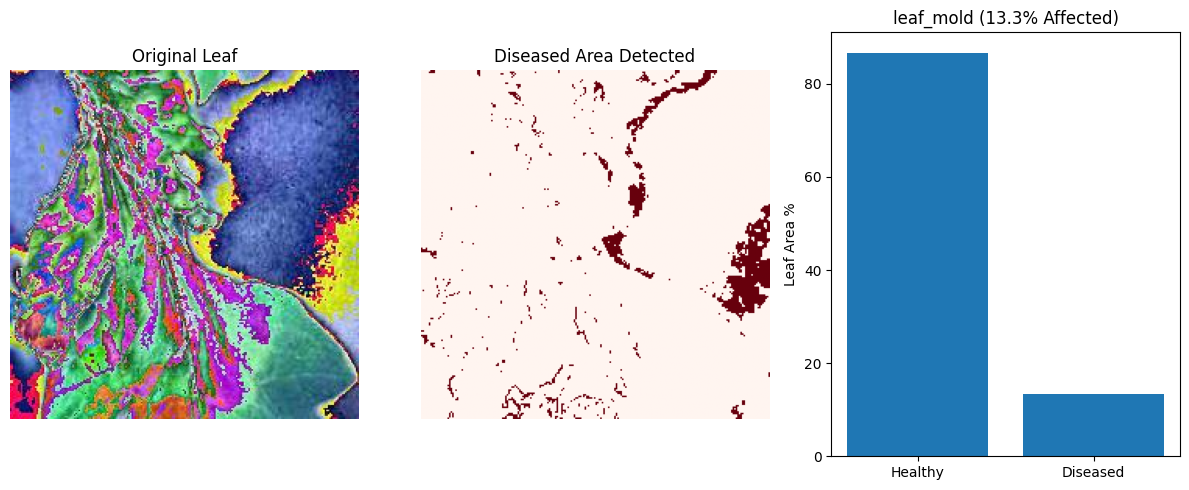


Example 2: With custom environment

🍅 TOMATO LEAF ANALYSIS RESULT
🔬 Predicted Disease: leaf_mold
📊 Confidence: 100.0%
🍃 Leaf Area Affected: 15.9%
⚠️  Severity: Low
💡 Action: Monitor


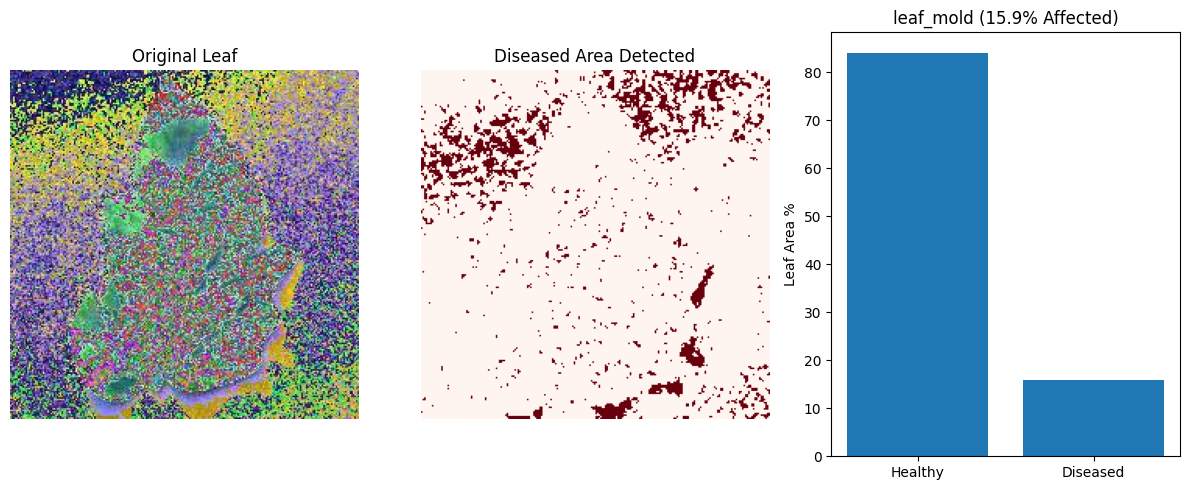

In [31]:
print("\nExample 1: Analyze single leaf")
result1 = analyze_farm_leaf('/content/temp_leaf_14.jpg')

print("\nExample 2: With custom environment")
result2 = analyze_farm_leaf('/content/temp_leaf_0.jpg', temperature=30, humidity=85, stage=4)